## Problem 4: 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

In [6]:
retail_data = pd.read_csv('RSFHFS.csv', header=0, index_col=0, na_values='.')
retail_data.index = pd.to_datetime(retail_data.index)
retail_data = retail_data.ffill()
retail_data.columns = ['sales']

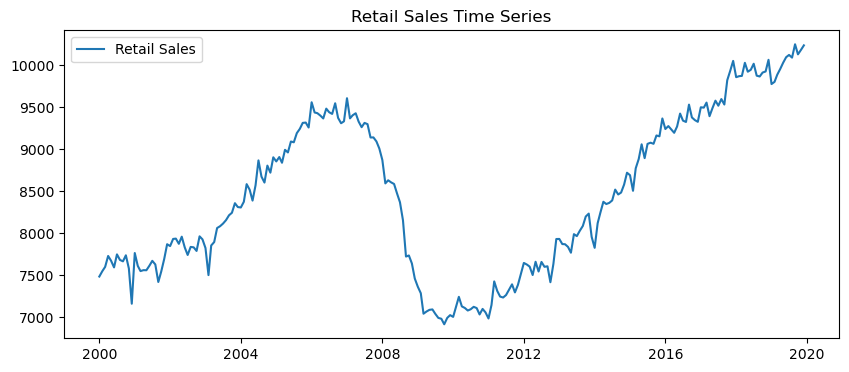

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(retail_data, label='Retail Sales')
plt.title("Retail Sales Time Series")
plt.legend()
plt.show()

## The choice between an ARMA (AutoRegressive Moving Average) and an ARIMA (AutoRegressive Integrated Moving Average) model depends on whether the time series is stationary or non-stationary. 
For ARMA(p,q)

Suitable for stationary time series (i.e., mean and variance do not change over time).
It consists of an AutoRegressive (AR) component of order 𝑝 and a Moving Average (MA) component of order q.

For ARIMA(p,d,q)
Suitable for non-stationary time series.
Includes an Integration (I) component 𝑑 that differentiates the data to make it stationary.
If d=0, the ARIMA model reduces to an ARMA model.
Check for stationarity: Use the Augmented Dickey-Fuller (ADF) test or KPSS test to determine if the series is stationary.
If the series is stationary: Use ARMA
If the series is non-stationary: Use ARIMA (after differencing d times to get the statonarity)

In [11]:
train = retail_data[:'2015']
test = retail_data['2016':]

In [211]:
import itertools
p_values = range(3)
d_values = range(2)
q_values = range(3)
best_aic = np.inf
best_order = None
best_model = None

In [213]:
for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order = order, freq = 'MS')
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = order
            best_model = model.fit()
    except Exception as e:
        print(f"Error with order {order}: {e}")
        continue

(f"Best ARIMA model order: {best_order}")

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be use

'Best ARIMA model order: (2, 1, 2)'

In [214]:
res = best_model

In [217]:
forecast = res.get_forecast(steps=len(test))
fc = forecast.summary_frame()

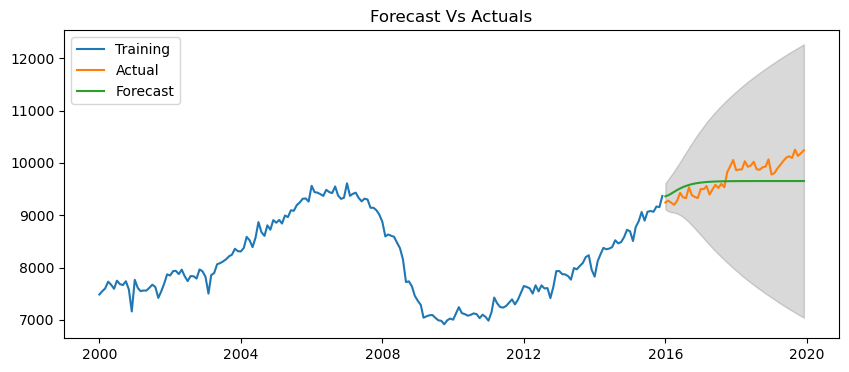

In [219]:
plt.figure(figsize=(10, 4))
plt.plot(train, label='Training')
plt.plot(test, label='Actual')
plt.plot(fc['mean'], label='Forecast')
plt.fill_between(fc.index, fc['mean_ci_lower'], fc['mean_ci_upper'], color='k', alpha=0.15)
plt.title('Forecast Vs Actuals')
plt.legend()
plt.show()

In [221]:
def forecast_accuracy(forecast, actual):
    mae = np.mean(np.abs(forecast - actual))
    rmse = np.sqrt(np.mean((forecast - actual) ** 2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return { 'MAE': mae, 'RMSE': rmse, 'MAPE': mape }

accuracy = forecast_accuracy(fc['mean'], test['sales'])
print(accuracy)

{'MAE': 254.72006134115807, 'RMSE': 290.44985121118657, 'MAPE': 2.5864637699107784}


## Problem 5:

In [131]:
djia_data = pd.read_csv('DJIA.csv', header=0, index_col=0, na_values='.')
djia_data.index = pd.to_datetime(djia_data.index)
djia_data = djia_data.ffill()
djia_data.columns = ['price']

In [134]:
djia_data['return'] = djia_data['price'].pct_change() * 100
djia_data['sqret'] = djia_data['return']**2

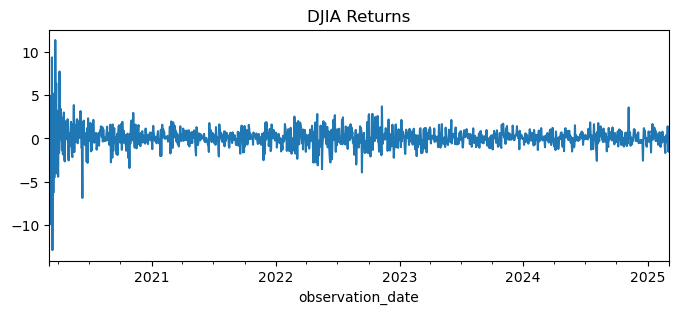

In [137]:
djia_data['return'].plot(figsize=(8,3), title='DJIA Returns')
plt.show()

## Based on the figure, the ARCH (Autoregressive Conditional Heteroskedasticity) family of models is more appropriate for modeling the DJIA returns rather than an ARMA model. Here’s why:

Volatility Clustering: The figure shows periods of high and low volatility, where large fluctuations tend to cluster together. This suggests that the variance of returns is not constant over time, which is a characteristic of heteroskedasticity.
Stationary Mean: The return series appears to fluctuate around a constant mean, suggesting that it is already stationary and does not need differencing (which would be required for ARIMA models).
Squared Returns (Volatility Proxy): The second plot (showing squared returns) exhibits persistent periods of high and low values, reinforcing the idea of time-varying volatility.

We should select ARCH or GARCH instead of ARMA model because of the following:
ARMA models are designed for modeling the mean of a stationary time series but assume constant variance (homoskedasticity). Since the DJIA returns exhibit time-varying volatility, an ARMA model would not effectively capture this behavior.
ARCH/GARCH models explicitly model conditional heteroskedasticity, meaning they account for how volatility changes over time.

For this dataset, an ARCH or GARCH model would be better suited than an ARMA model, as it can capture the time-varying volatility observed in financial return series.

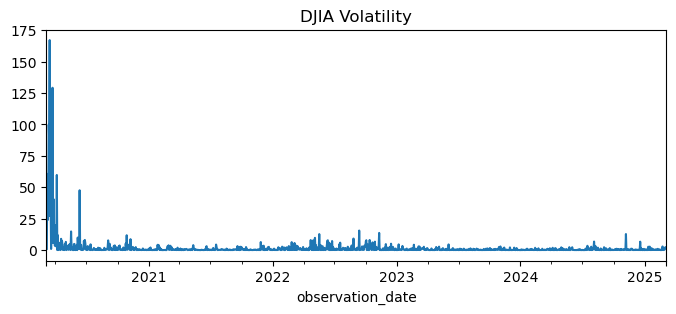

In [141]:
djia_data['sqret'].plot(figsize=(8,3), title='DJIA Volatility')
plt.show()

In [144]:
model_arch = arch_model(djia_data['return'].dropna(), mean='Constant', vol='ARCH', p=2)
res_arch = model_arch.fit(update_freq=2)
print(res_arch.summary())

Iteration:      2,   Func. Count:     14,   Neg. LLF: 679701744.5731144
Iteration:      4,   Func. Count:     26,   Neg. LLF: 1889.385440408121
Iteration:      6,   Func. Count:     40,   Neg. LLF: 1806.375271866303
Iteration:      8,   Func. Count:     50,   Neg. LLF: 1806.3299241708053
Iteration:     10,   Func. Count:     59,   Neg. LLF: 1806.3298962597482
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1806.329896259716
            Iterations: 10
            Function evaluations: 59
            Gradient evaluations: 10
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1806.33
Distribution:                  Normal   AIC:                           3620.66
Method:            Maximum Likelih

In [147]:
model_garch = arch_model(djia_data['return'].dropna(), mean='Constant', vol='GARCH', p=1, q=1)
res_garch = model_garch.fit(update_freq=2)
print(res_garch.summary())

Iteration:      2,   Func. Count:     14,   Neg. LLF: 4983637725.7776375
Iteration:      4,   Func. Count:     29,   Neg. LLF: 2184.6899373477136
Iteration:      6,   Func. Count:     42,   Neg. LLF: 1731.0430238091963
Iteration:      8,   Func. Count:     52,   Neg. LLF: 1731.042776076528
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1731.042776076528
            Iterations: 8
            Function evaluations: 52
            Gradient evaluations: 8
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1731.04
Distribution:                  Normal   AIC:                           3470.09
Method:            Maximum Likelihood   BIC:                           3490.78
                            